In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

try:
    df = pd.read_csv('../data/heart.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

# Summary statistics
print("\n--- Statistical Summary ---")
print(df.describe())

/home/wren/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Dataset loaded successfully.

--- First 5 Rows ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   t

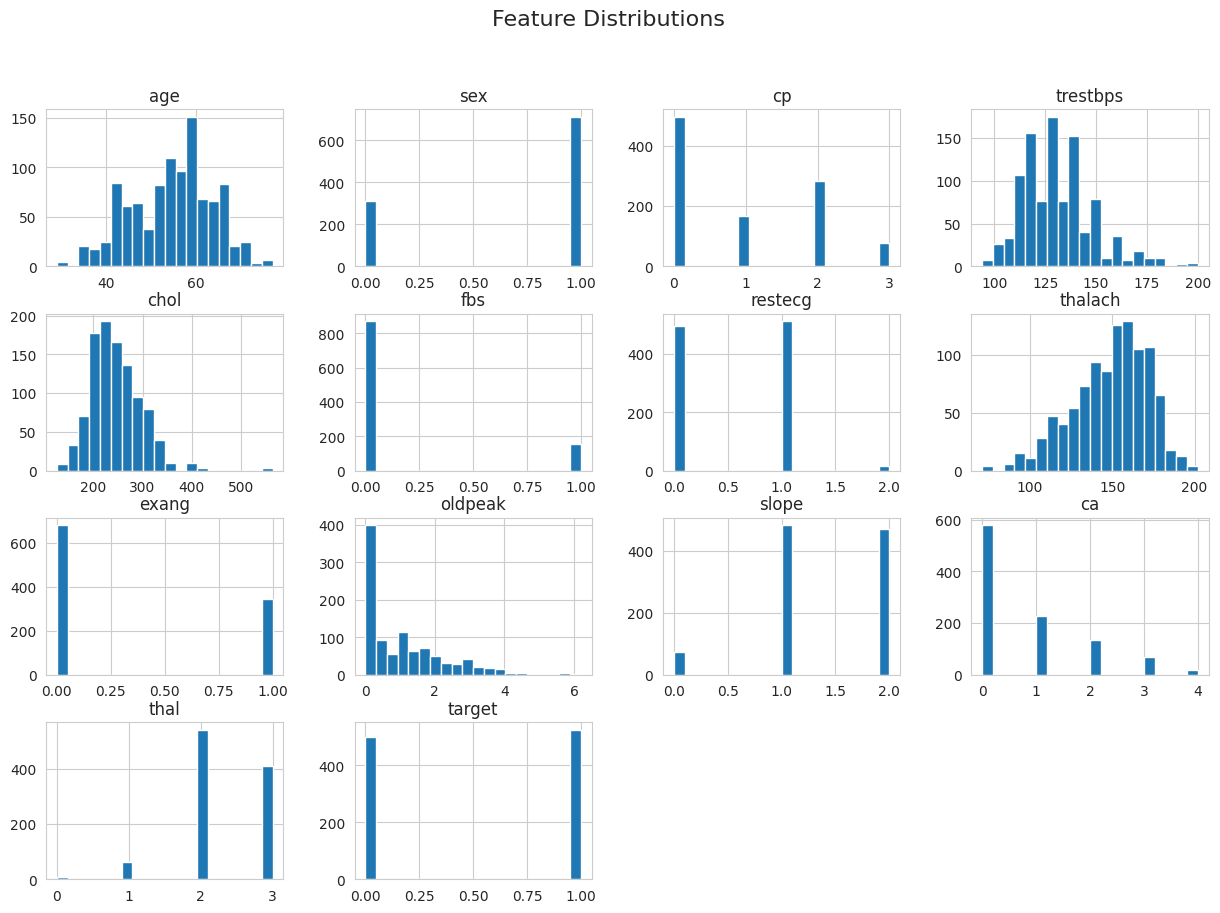

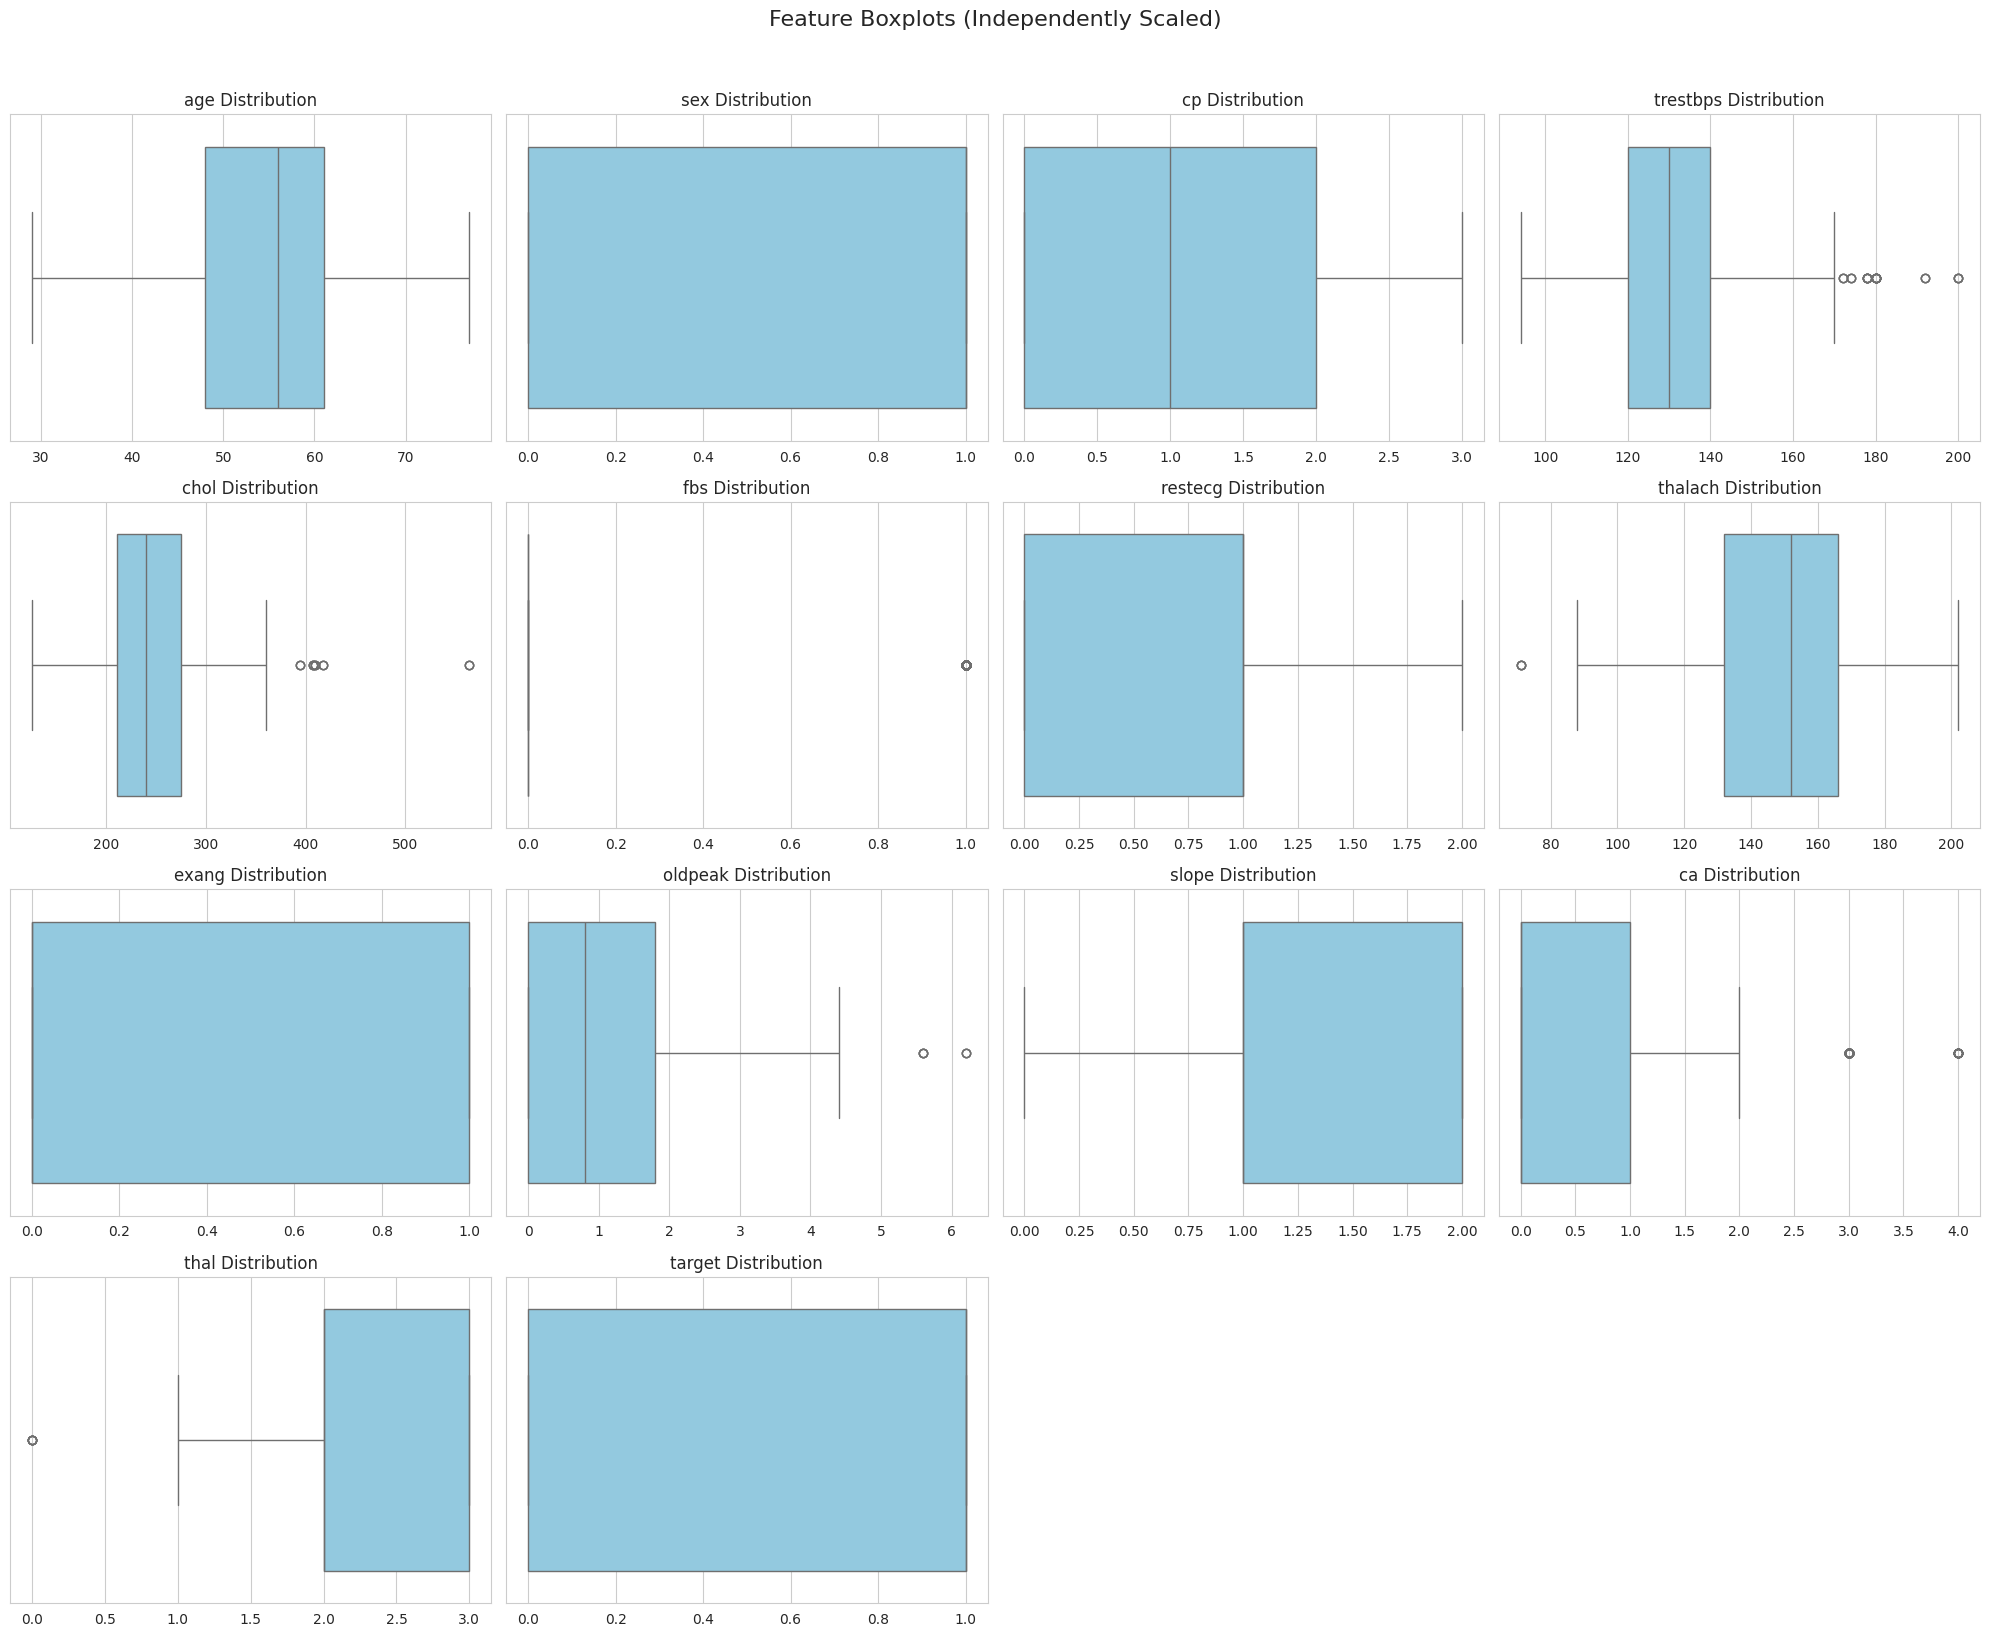

In [3]:
df.hist(bins=20, figsize=(15, 10), layout=(4, 4))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

n_cols = 4
n_features = len(df.columns)
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, n_rows * 4))  # Adjust total height based on rows

for i, column in enumerate(df.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    # Plot individual boxplot for each feature
    sns.boxplot(x=df[column], color='skyblue')
    plt.title(f'{column} Distribution', fontsize=12)
    plt.xlabel('')  # Clear x-label to reduce clutter

plt.suptitle("Feature Boxplots (Independently Scaled)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

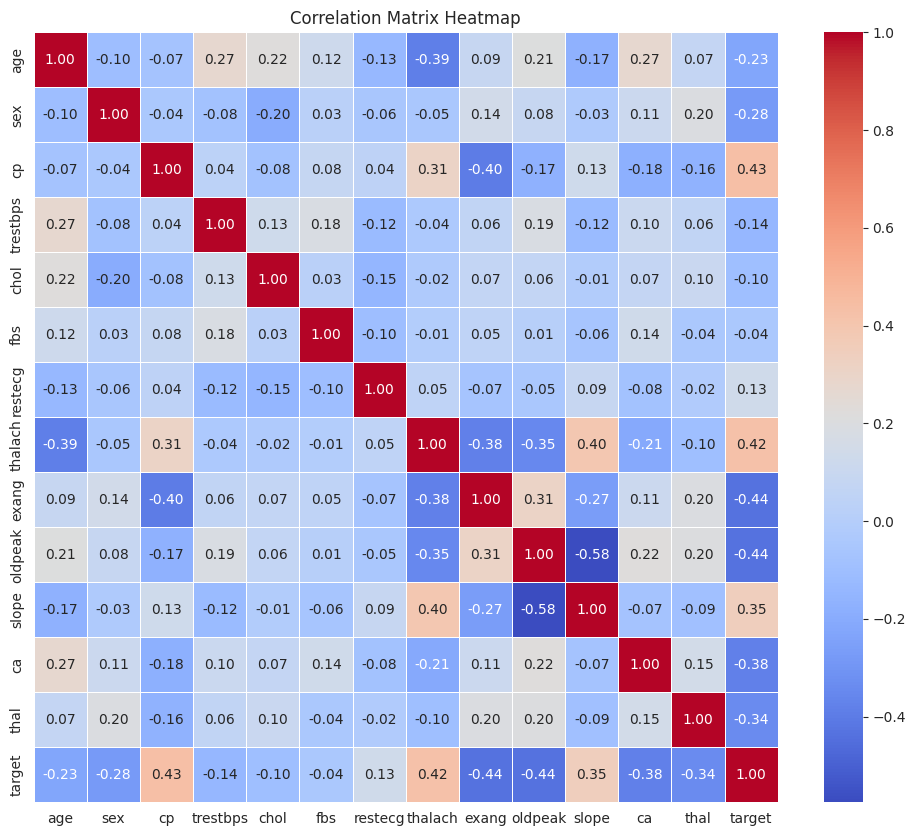


--- Highly Correlated Features (Threshold > 0.8) ---
No features found with correlation > 0.8


In [4]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

print("\n--- Highly Correlated Features (Threshold > 0.8) ---")
high_corr_var = np.where(np.abs(corr_matrix) > 0.8)
high_corr_var = [(corr_matrix.index[x], corr_matrix.columns[y])
                 for x, y in zip(*high_corr_var) if x != y and x < y]

if len(high_corr_var) == 0:
    print("No features found with correlation > 0.8")
else:
    for pair in high_corr_var:
        print(f"{pair[0]} and {pair[1]}")

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_csv('../data/heart.csv')
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

### Checking model without feature selection

In [6]:
model_lr = LogisticRegression(max_iter=5000, random_state=42)
model_lr.fit(X_train_std, y_train)
y_pred = model_lr.predict(X_test_std)
print("\n--- Logistic Regression Performance Without Feature Selection---")
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


--- Logistic Regression Performance Without Feature Selection---
0.8146341463414634
[[74 28]
 [10 93]]


In [7]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

mi_selector = SelectKBest(score_func=mutual_info_classif, k=5)
mi_selector.fit(X_train_std, y_train)

selected_mask = mi_selector.get_support()
selected_features = X.columns[selected_mask]
univariate_features = set(selected_features)

print("\n--- Univariate Selection (Mutual Information) ---")
print(f"Top 5 Features selected: {list(selected_features)}")

mi_scores = pd.Series(mi_selector.scores_, index=X.columns)
print("\nTop Feature Scores:")
print(mi_scores.sort_values(ascending=False).head(8))

X_train_uni = mi_selector.transform(X_train_std)
X_test_uni = mi_selector.transform(X_test_std)

model_uni = LogisticRegression(max_iter=5000, random_state=42)
model_uni.fit(X_train_uni, y_train)
y_pred_uni = model_uni.predict(X_test_uni)

acc_uni = accuracy_score(y_test, y_pred_uni)
print(f"\nUnivariate Model Accuracy (Top 5 features): {acc_uni:.4f}")

acc_full = accuracy_score(y_test, y_pred)
print(f"Full Model Accuracy: {acc_full:.4f}")

if acc_uni >= acc_full:
    print("Observation: Feature selection maintained or improved accuracy.")
else:
    print(f"Observation: Accuracy dropped by {(acc_full - acc_uni)*100:.2f}%.")


--- Univariate Selection (Mutual Information) ---
Top 5 Features selected: ['cp', 'chol', 'thalach', 'oldpeak', 'thal']

Top Feature Scores:
chol       0.261425
thalach    0.166155
thal       0.159236
cp         0.145654
oldpeak    0.145295
ca         0.129618
exang      0.107931
slope      0.097824
dtype: float64

Univariate Model Accuracy (Top 5 features): 0.7951
Full Model Accuracy: 0.8146
Observation: Accuracy dropped by 1.95%.


In [8]:
from sklearn.feature_selection import RFE

k = 5
rfe = RFE(estimator=model_lr, n_features_to_select=k)

print(f"Running RFE to select top {k} features...")
rfe.fit(X_train_std, y_train)

rfe_selected_features = X.columns[rfe.support_]

print(f"\n--- RFE Selected Features ---")
print(list(rfe_selected_features))

X_train_rfe = rfe.transform(X_train_std)
X_test_rfe = rfe.transform(X_test_std)

model_lr.fit(X_train_rfe, y_train)
y_pred_rfe = model_lr.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test, y_pred_rfe)

print(f"\nRFE Model Accuracy (Top {k} features): {acc_rfe:.4f}")


rfe_features_set = set(rfe_selected_features)

if univariate_features:
    overlap = rfe_features_set.intersection(univariate_features)
    print(f"\n--- Feature Overlap Analysis ---")
    print(f"Univariate Features: {univariate_features}")
    print(f"RFE Features:        {rfe_features_set}")
    print(f"Overlapping Features: {overlap}")
    print(f"Number of common features: {len(overlap)}")

Running RFE to select top 5 features...

--- RFE Selected Features ---
['cp', 'thalach', 'oldpeak', 'ca', 'thal']

RFE Model Accuracy (Top 5 features): 0.7854

--- Feature Overlap Analysis ---
Univariate Features: {'oldpeak', 'cp', 'thalach', 'chol', 'thal'}
RFE Features:        {'oldpeak', 'cp', 'ca', 'thalach', 'thal'}
Overlapping Features: {'oldpeak', 'cp', 'thal', 'thalach'}
Number of common features: 4


Running RFECV (this may take a moment)...



Optimal number of features: 11
Selected Features: ['sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


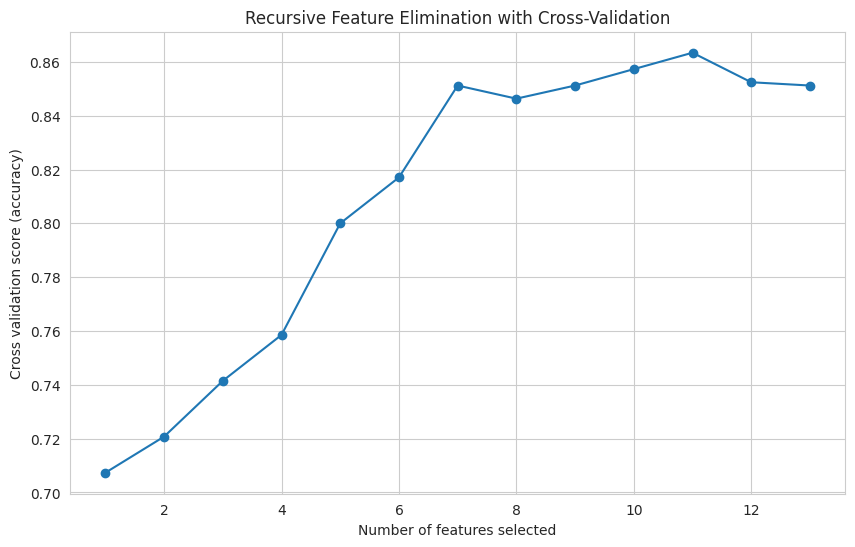

In [9]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt


rfecv = RFECV(
    estimator=model_lr,
    step=1,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    min_features_to_select=1
)

print("Running RFECV (this may take a moment)...")
rfecv.fit(X_train, y_train)

optimal_n_features = rfecv.n_features_
print(f"\nOptimal number of features: {optimal_n_features}")

rfecv_selected_features = X.columns[rfecv.support_]
print(f"Selected Features: {list(rfecv_selected_features)}")

n_scores = len(rfecv.cv_results_["mean_test_score"])
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (accuracy)")
plt.plot(
    range(1, n_scores + 1),
    rfecv.cv_results_["mean_test_score"],
    marker='o'
)
plt.title("Recursive Feature Elimination with Cross-Validation")
plt.show()

--- Lasso Selected Features (12) ---
['sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


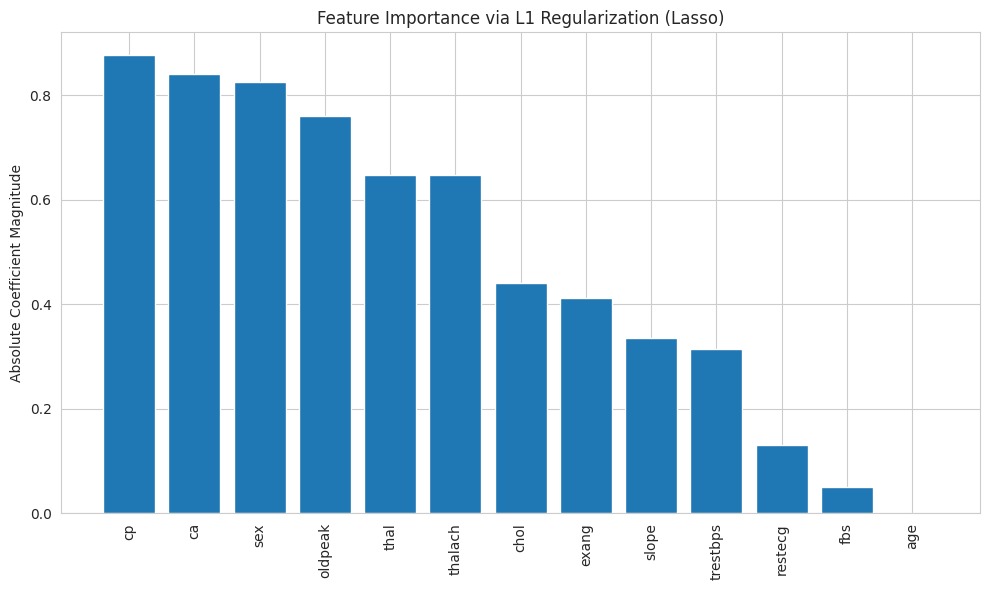


--- Method Comparison ---
Lasso features: 12
RFE features:   5
Overlap (Lasso & RFE): {'oldpeak', 'cp', 'ca', 'thalach', 'thal'}


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_model = LogisticRegression(
    penalty='l1', C=1.0, solver='liblinear', random_state=42)
lasso_model.fit(X_train_scaled, y_train)


coefs = lasso_model.coef_.flatten()

selected_mask = coefs != 0
lasso_selected_features = X.columns[selected_mask]

print(f"--- Lasso Selected Features ({len(lasso_selected_features)}) ---")
print(list(lasso_selected_features))

plt.figure(figsize=(10, 6))
indices = np.argsort(np.abs(coefs))[::-1]

plt.title("Feature Importance via L1 Regularization (Lasso)")
plt.bar(range(X.shape[1]), np.abs(coefs[indices]), align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.ylabel('Absolute Coefficient Magnitude')
plt.tight_layout()
plt.show()


try:
    rfe_set = set(rfe_selected_features)
except NameError:
    rfe_set = set()

try:
    uni_set = set(selected_features)
except NameError:
    uni_set = set()

lasso_set = set(lasso_selected_features)

print("\n--- Method Comparison ---")
print(f"Lasso features: {len(lasso_set)}")
print(f"RFE features:   {len(rfe_set)}")
print(f"Overlap (Lasso & RFE): {lasso_set.intersection(rfe_set)}")


--- PCA Variance Analysis ---
Components needed for 90% variance: 11
Components needed for 95% variance: 12
Total features in original dataset: 13


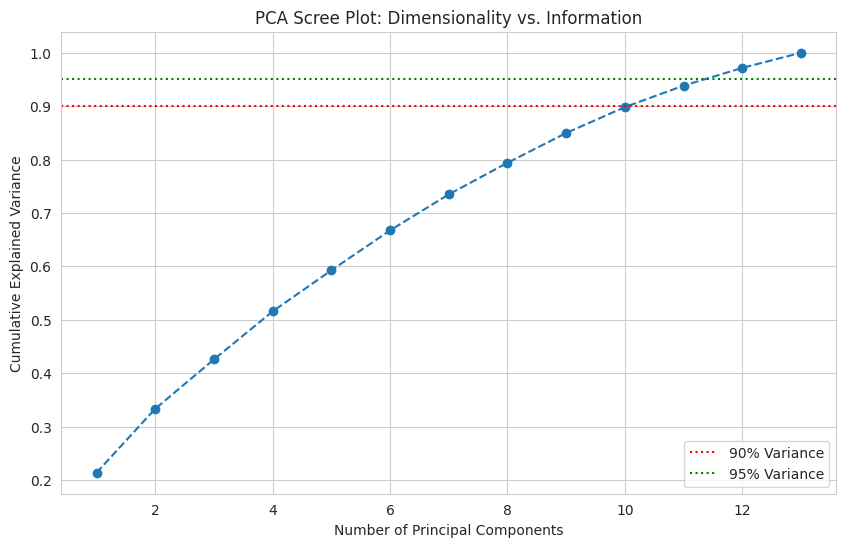


--- Final Comparison: Dimensionality vs. Selection ---
Features selected by RFE (fixed):   5
Features selected by RFECV (optimal): 11
PCA Components for 95% info:        12


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\n--- PCA Variance Analysis ---")
print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Total features in original dataset: {X.shape[1]}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle=':', label='95% Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot: Dimensionality vs. Information')
plt.legend()
plt.grid(True)
plt.show()

try:
    rfe_count = 5
    rfecv_count = optimal_n_features
except NameError:
    rfe_count = 5
    rfecv_count = "Unknown (RFECV not run)"

print(f"\n--- Final Comparison: Dimensionality vs. Selection ---")
print(f"Features selected by RFE (fixed):   {rfe_count}")
print(f"Features selected by RFECV (optimal): {rfecv_count}")
print(f"PCA Components for 95% info:        {n_95}")